# 4. Bandes de phonons 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)
    phonon_bs = mpr.get_phonon_bandstructure_by_material_id(MP_ID)


/home/marfa/Projet_PhysMat/notebook_env/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 4.1 Télécharger la structure de bandes de phonons du matériau attribué ainsi que sa zone de Brillouin

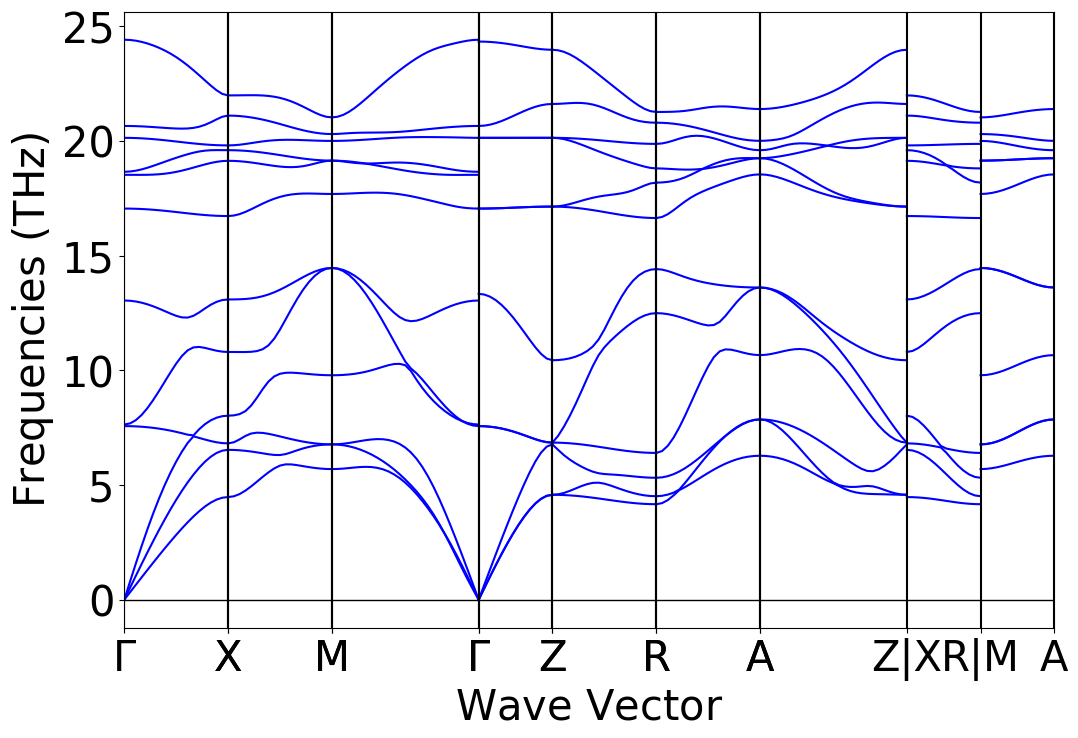

In [2]:
plotter = PhononBSPlotter(phonon_bs)
fig = plotter.get_plot()  

plt.savefig(f"{MP_ID}_phonon_bandstructure.png", dpi=300, bbox_inches="tight")
plt.show()

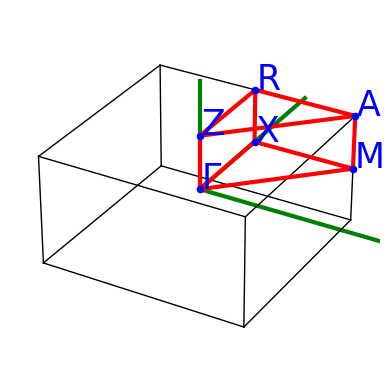

In [3]:
# Zone de Brillouin
ph_plot = PhononBSPlotter(phonon_bs)
ph_plot.plot_brillouin()

## 4.2 déterminer les trois premiers pics du diffractogramme correspondant (en indiquant les indices hkl associés) pour un rayonnement X incident Cu Kα de longueur d'onde λ=1.54060 Å.

Attention il faut mettre cette partie dans structure cristalline

L'intensité des rayons diffusés par un cristal sera maximale si les rayons reflechis par les différents plans cristallins successifs interfèrent de manière constructive. Cette condition correspond à une réflexion spéculaire, c'est à dire que le faisceau de lumière rebondit sur une surface lisse et polie et est reflechi dans une seule et unique direction (la loi de la reflexion est respectée : angle d'incidence = angle de reflexion), sur les plans du réseau cristallin.

loi de Bragg nous donne la condition d'interference constructive : n\lambda = 2d_{hkl} \sin(theta) 

n = ordre de diffraction

lambda = longueur d'onde du rayonnement incident 

d_{hkl} = distance interréticulaire associée au plan cristallin (hkl)
la distance interréticulaire d_{hkl} correspond à la distance entre deux plans (h k l) consécutifs du réseau direct. Elle est liée à la norme du vecteur v = (h,k,l) du réseau réciproque par la relation : v = ha* + kb* + lc* -> d_{hkl} = 2pi/|v|

theta = angle de diffraction

Les pics du diffractogramme apparaissent donc lorsque la condition de Bragg est satisfaite pour certaines familles de plans cristallins (hkl).
Dans notre cas, les positions des pics sont calculées pour une source de rayons X CuKa de longueur d'onde 1,54060 Å.
Les positions des pics sont directement liées aux distances interréticulaires 
d_{hkl} associées à ces plans.

j'ai mis ceci dans la partie phonon est ce cohérent (ou plutot dans la partie electrons ) ?

In [4]:
# Source Cu Ka par défaut : 1.5406 A
calcul = XRDCalculator(wavelength=1.54060)
pattern = calcul.get_pattern(structure, two_theta_range=(0, 90)) # calcul des pics entre 0° et 90°

print(f"3 premiers pics du diffractogramme pour {structure.composition.reduced_formula} :\n")

for i in range(3):
    angle = pattern.x[i] # position des pics
    intensite = pattern.y[i] # intensité relative
    hkl_dict = pattern.hkls[i][0] # On prend le premier hkl si multiplicités car un pic peut correspondre à plusieurs plans (hkl) équivalents; indices de Miller reponsable du pic
    hkl_label = hkl_dict['hkl'] # distances interréticulaires
    multiplicity = hkl_dict['multiplicity'] # La multiplicité correspond au nombre de plans équivalents dans le cristal.
    d_spacing = pattern.d_hkls[i] # distance entre les plans cristallins en Ångström.
    
    print(f"Pic n°{i+1}:")
    print(f"  - Angle 2θ : {angle:.4f}°")
    print(f"  - Indices hkl : {hkl_label}")
    print(f"  - Distance interréticulaire d : {d_spacing:.4f} Å")
    print(f"  - Intensité relative : {intensite:.2f} %")
    print("-" * 30)

3 premiers pics du diffractogramme pour AlGaN2 :

Pic n°1:
  - Angle 2θ : 20.0555°
  - Indices hkl : (0, 0, 1)
  - Distance interréticulaire d : 4.4238 Å
  - Intensité relative : 17.29 %
------------------------------
Pic n°2:
  - Angle 2θ : 28.3932°
  - Indices hkl : (1, 0, 0)
  - Distance interréticulaire d : 3.1409 Å
  - Intensité relative : 17.03 %
------------------------------
Pic n°3:
  - Angle 2θ : 35.0086°
  - Indices hkl : (1, 0, 1)
  - Distance interréticulaire d : 2.5610 Å
  - Intensité relative : 100.00 %
------------------------------


Les trois premiers pics du diffractogramme calculé pour le matériau AlGaN₂ apparaissent aux angles 2θ = 20.06°,28.39° et 35.01°. Ils correspondent respectivement aux familles de plans cristallins (001), (100) et (101).

On observe que le premier pic, situé à plus faible angle, correspond à la plus grande distance interréticulaire (d=4.42 Å), tandis que les pics apparaissant à des angles plus élevés sont associés à des distances interplanaires plus faibles (d=3.14 Å et 2.56 Å). Cette évolution est cohérente avec la relation donnée par la loi de Bragg.

Le pic le plus intense correspond au plan (101), avec une intensité relative de 100 %, indiquant que cette famille de plans contribue fortement au signal de diffraction pour cette structure cristalline.

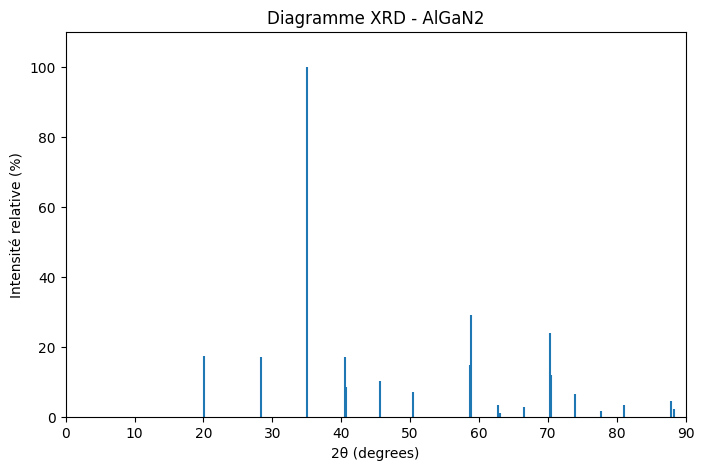

In [5]:
plt.figure(figsize=(8,5))
plt.vlines(pattern.x, 0, pattern.y)

plt.xlabel("2θ (degrees)")
plt.ylabel("Intensité relative (%)")
plt.title(f"Diagramme XRD - {structure.composition.reduced_formula}")

plt.xlim(0,90)
plt.ylim(0,110)

plt.show()

Les positions des pics obtenus sont cohérentes avec les paramètres de maille du matériau AlGaN₂ rapportés dans la base de données Materials Project, soit 
a=b=3.14 Å et c=4.42 Å pour une maille tétragonale.

Pour le plan (001), la distance interréticulaire correspond directement au paramètre c, ce qui donne d ≈ 4.42 Å, en accord avec la valeur obtenue d = 4.4238 Å. De même, pour le plan (100), la distance interréticulaire correspond au paramètre a, soit d ≈ 3.14 Å, ce qui est cohérent avec la valeur calculée d = 3.1409 Å.

Pour le plan (101), la distance interréticulaire peut être obtenue à partir de la relation valable pour une maille tétragonale 1/d²_{hkl} = (h²+k²)/a² + l²/c²
ce qui conduit à d≈2.56 Å, en excellent accord avec la valeur calculée d = 2.5610 Å.

## 4.3 calculer la vitesse du son pour trois branches acoustiques différentes dans trois directions différentes de la zone de Brillouin;

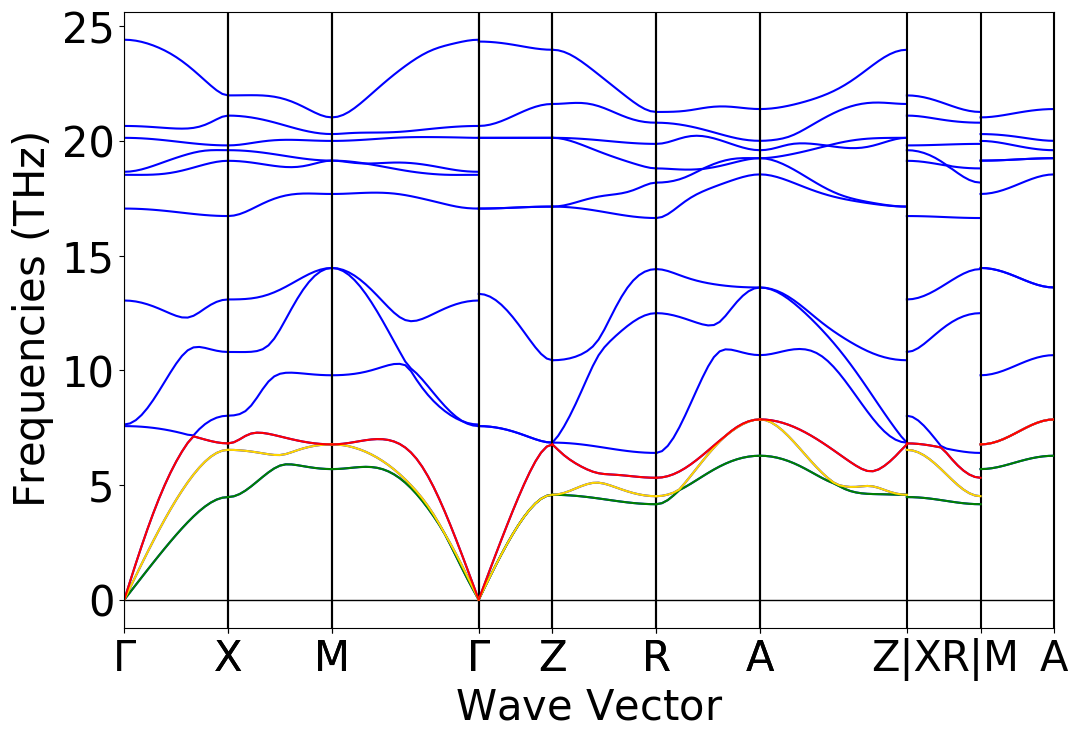

In [11]:
data = PhononBSPlotter(phonon_bs).bs_plot_data()
distances = data['distances']
frequences = data['frequency']
directions = data['ticks']['label']

ph_plot.get_plot()

for i in range(len(distances)):
    plt.plot(distances[i], frequences[i][0], 'green')
    plt.plot(distances[i], frequences[i][1], 'gold')
    plt.plot(distances[i], frequences[i][2], 'red')


In [7]:
conversion = 1e12 / 1e10
# Vitesse v = 2 * pi * df / dq

# signification des indices de frequences : [chemin/e/2points][branche][val_freq_pour_ce_point]
# signification des indices de distances : [chemin/e/2points][coord_q_axeH]

# 1ere branche acoustique Gamma - X
d_freq1 = (frequences[0][2][1] - frequences[0][2][0])
d_dist1 = distances[0][1] - distances[0][0]

v_1 = np.abs(2 * np.pi * (d_freq1 / d_dist1) * conversion)
print(f"La vitesse du son pour la branche Γ-X de la zone de Brillouin :  {v_1:.2f} [m/s]")

# 2eme branche acoustique Gamma - Z
d_freq2 = frequences[3][2][1] - frequences[3][2][0]
d_dist2 = distances[3][1] - distances[3][0]

v_2 =  np.abs(2 * np.pi * (d_freq2 / d_dist2) * conversion)
print(f"La vitesse du son pour la branche Γ-Z de la zone de Brillouin : {v_2:.2f} [m/s]")

# 3eme branhce acoustiqye Gamma - M
d_freq3 = frequences[2][2][-1] - frequences[2][2][-2]
d_dist3 = distances[2][-1] - distances[2][-2]

v_3 =  np.abs(2 * np.pi * (d_freq3 / d_dist3) * conversion)
print(f"La vitesse du son pour la branche X-M de la zone de Brillouin : {v_3:.2f} [m/s]")

La vitesse du son pour la branche Γ-X de la zone de Brillouin :  8964.42 [m/s]
La vitesse du son pour la branche Γ-Z de la zone de Brillouin : 7602.32 [m/s]
La vitesse du son pour la branche X-M de la zone de Brillouin : 7694.99 [m/s]


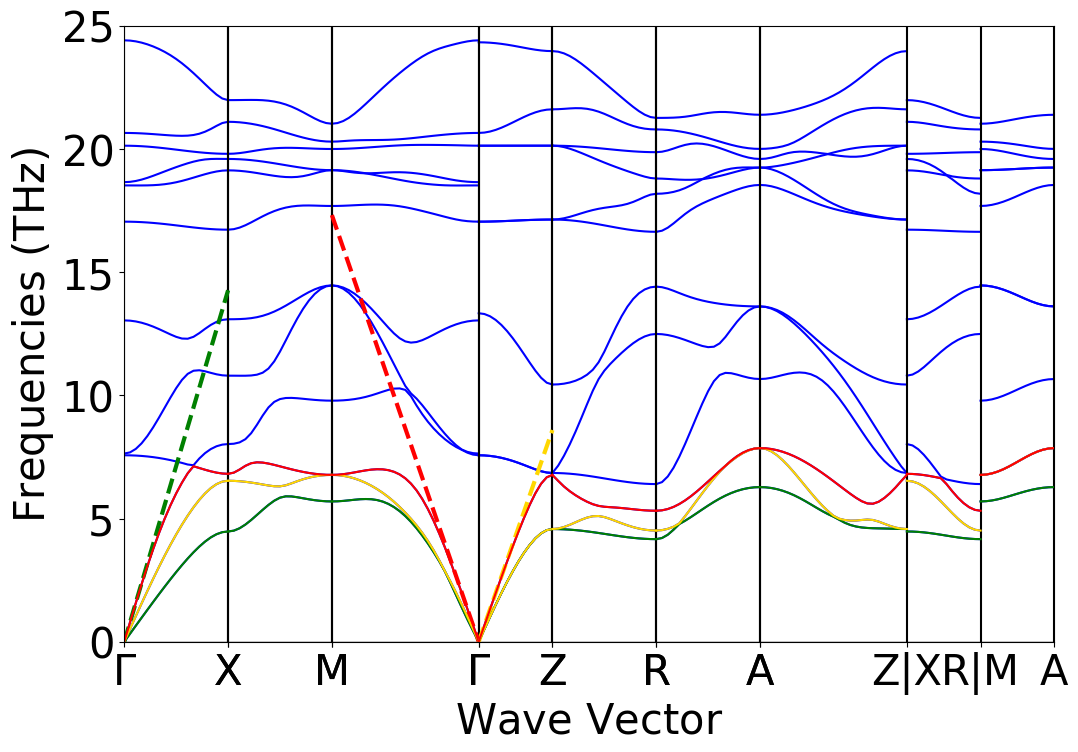

In [8]:
ph_plot.get_plot()
plt.plot()

# direction 1
x1 = np.array([distances[0][0], distances[0][1]])
y1 = np.array([frequences[0][2][0], frequences[0][2][1]])
c1 = np.polyfit(x1, y1, 1)
a1 = np.linspace(distances[0][0], distances[0][-1], 100)
p1 = c1[0]*a1 + c1[1]

# direction 2
x2 = np.array([distances[3][0], distances[3][1]])
y2 = np.array([frequences[3][2][0], frequences[3][2][1]])
c2 = np.polyfit(x2, y2, 1)
a2 = np.linspace(distances[3][0], distances[3][-1], 100)
p2 = c2[0]*a2 + c2[1]

# direction 3
x3 = np.array([distances[2][-2], distances[2][-1]])
y3 = np.array([frequences[2][2][-2], frequences[2][2][-1]])
c3 = np.polyfit(x3, y3, 1)
a3 = np.linspace(distances[2][0], distances[2][-1], 100)
p3 = c3[0]*a3 + c3[1]


plt.plot(a1, p1, color ="green", ls='--', lw = 3)
plt.plot(a2, p2, color ="gold", ls='--', lw = 3)
plt.plot(a3, p3, color='red', ls='--', lw = 3)
plt.ylim(0,25)
for i in range(len(distances)):
    plt.plot(distances[i], frequences[i][0], 'green')
    plt.plot(distances[i], frequences[i][1], 'gold')
    plt.plot(distances[i], frequences[i][2], 'red')